# FFT Analysis — tremor_250
Power spectrum dos três eixos IMU (ch15=X, ch16=Y, ch17=Z).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [2]:
FILE = 'recordings/test8_tremor_250_levelA_20260619_122154.csv'
df = pd.read_csv(
    FILE, skiprows=5, header=None,
    names=['time_s','Thumb','Index','Middle','Ring','Pinky','ch15','ch16','ch17']
)
df = df[pd.to_numeric(df['time_s'], errors='coerce').notna()].reset_index(drop=True)
df = df.astype(float)

t  = df['time_s'].values
x  = df['ch15'].values
y  = df['ch16'].values
z  = df['ch17'].values
fs = 1.0 / np.mean(np.diff(t))

print(f'Samples: {len(t)}  |  Duration: {t[-1]:.2f} s  |  fs ≈ {fs:.1f} Hz')


Samples: 1204  |  Duration: 20.00 s  |  fs ≈ 60.2 Hz


## Power Spectrum — escala linear
Média removida antes da FFT para eliminar componente DC.

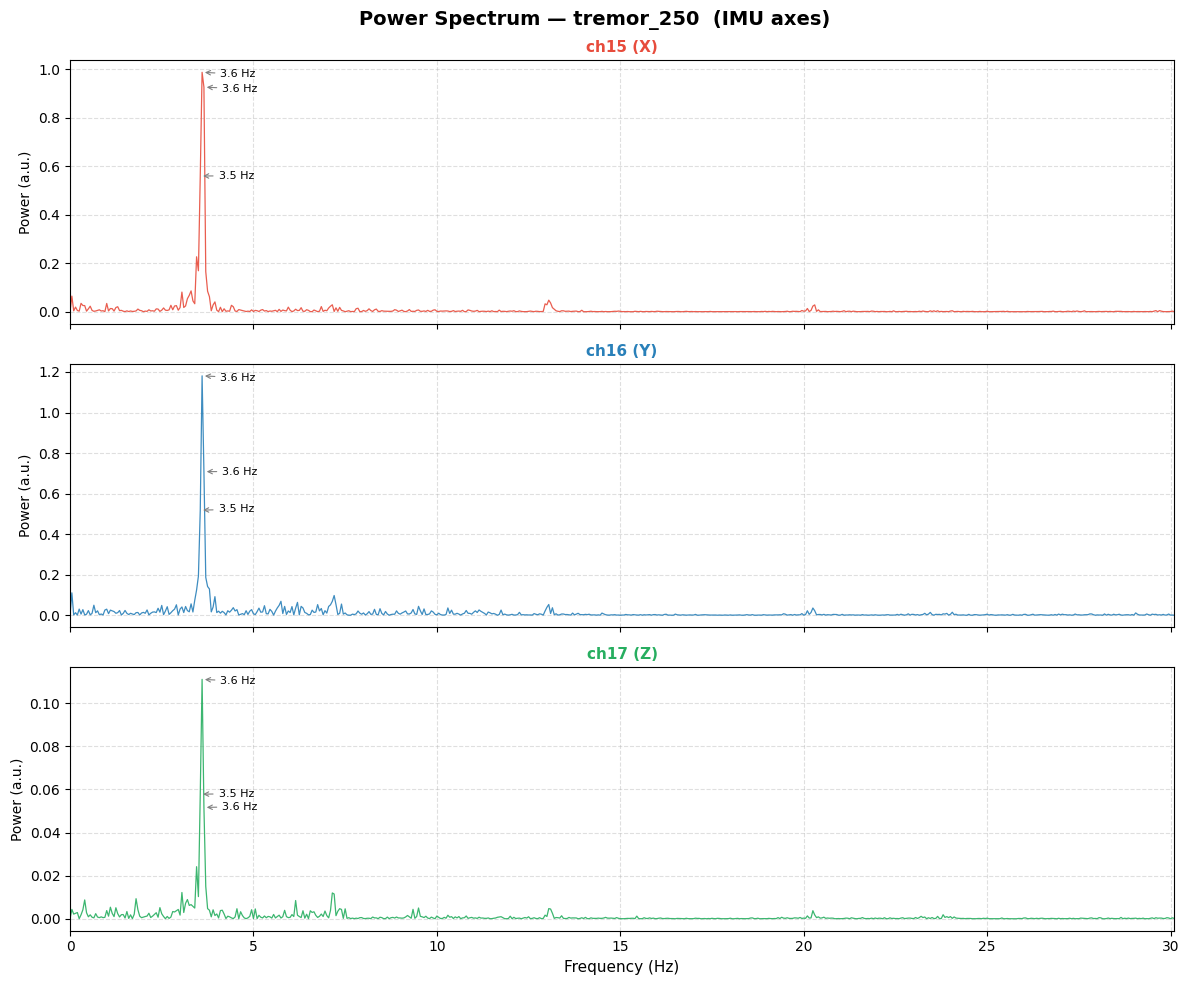

In [3]:
def power_spectrum(sig, fs):
    s = sig - sig.mean()
    fft_vals = np.fft.rfft(s)
    freqs    = np.fft.rfftfreq(len(s), d=1.0/fs)
    power    = (np.abs(fft_vals) ** 2) / len(s)
    return freqs, power

fx, px = power_spectrum(x, fs)
fy, py = power_spectrum(y, fs)
fz, pz = power_spectrum(z, fs)

axes_data = [
    (fx, px, 'ch15 (X)', '#e74c3c'),
    (fy, py, 'ch16 (Y)', '#2980b9'),
    (fz, pz, 'ch17 (Z)', '#27ae60'),
]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Power Spectrum — tremor_250  (IMU axes)', fontsize=14, fontweight='bold')

for ax, (freqs, power, label, color) in zip(axs, axes_data):
    ax.plot(freqs, power, color=color, linewidth=0.9, alpha=0.9)
    ax.set_ylabel('Power (a.u.)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlim(0, fs / 2)
    ax.grid(True, linestyle='--', alpha=0.4)
    peak_idx = np.argsort(power[1:])[::-1][:3] + 1
    for pi in peak_idx:
        ax.annotate(
            f'{freqs[pi]:.1f} Hz',
            xy=(freqs[pi], power[pi]),
            xytext=(freqs[pi] + 0.5, power[pi] * 0.98),
            fontsize=8, color='black',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        )

axs[-1].set_xlabel('Frequency (Hz)', fontsize=11)
plt.tight_layout()
plt.savefig('tremor250_power_spectrum_axes.png', dpi=150, bbox_inches='tight')
plt.show()


## Power Spectrum — escala dB
Revela picos mais pequenos escondidos na escala linear.

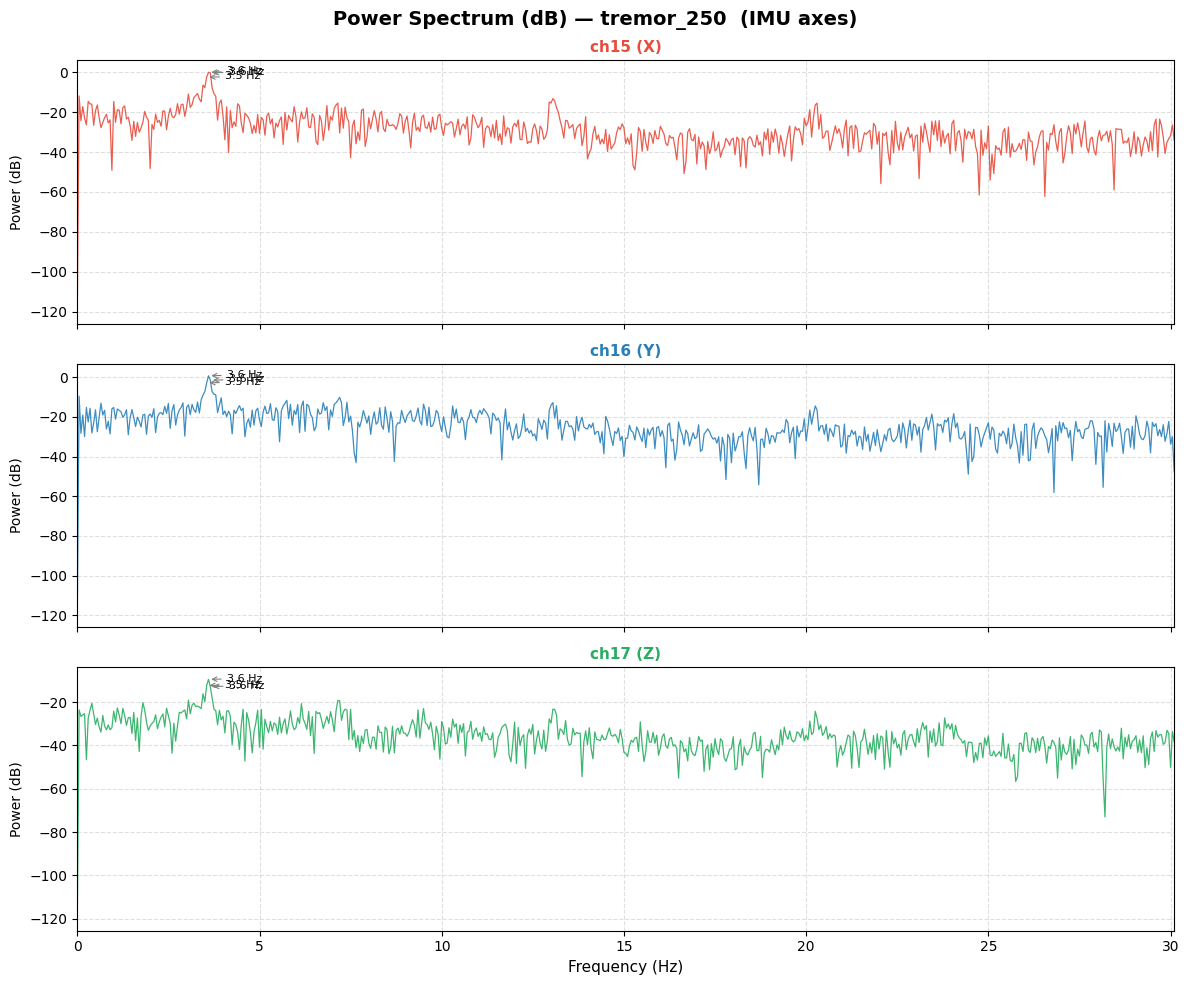

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Power Spectrum (dB) — tremor_250  (IMU axes)', fontsize=14, fontweight='bold')

for ax, (freqs, power, label, color) in zip(axs, axes_data):
    power_db = 10 * np.log10(power + 1e-12)
    ax.plot(freqs, power_db, color=color, linewidth=0.9, alpha=0.9)
    ax.set_ylabel('Power (dB)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlim(0, fs / 2)
    ax.grid(True, linestyle='--', alpha=0.4)
    peak_idx = np.argsort(power[1:])[::-1][:3] + 1
    for pi in peak_idx:
        pdb = 10 * np.log10(power[pi] + 1e-12)
        ax.annotate(
            f'{freqs[pi]:.1f} Hz',
            xy=(freqs[pi], pdb),
            xytext=(freqs[pi] + 0.5, pdb - 1),
            fontsize=8, color='black',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        )

axs[-1].set_xlabel('Frequency (Hz)', fontsize=11)
plt.tight_layout()
plt.savefig('tremor250_power_spectrum_axes_dB.png', dpi=150, bbox_inches='tight')
plt.show()


## Picos dominantes por eixo

In [5]:
header = f"{'Eixo':<12} {'Freq (Hz)':>10} {'Power':>14}"
print(header)
print('-' * 40)
for freqs, power, label, _ in axes_data:
    peaks, _ = find_peaks(power[1:], height=power[1:].max() * 0.05)
    peaks += 1
    top = sorted(zip(power[peaks], freqs[peaks]), reverse=True)[:5]
    for pw, fr in top:
        print(f'{label:<12} {fr:>10.2f} {pw:>14.4e}')
    print()


Eixo          Freq (Hz)          Power
----------------------------------------
ch15 (X)           3.60     9.8710e-01
ch15 (X)           3.45     2.2637e-01
ch15 (X)           3.30     8.5836e-02
ch15 (X)           3.05     8.0850e-02

ch16 (Y)           3.60     1.1811e+00
ch16 (Y)           7.20     9.7321e-02
ch16 (Y)           3.95     9.1651e-02
ch16 (Y)           5.75     6.8708e-02
ch16 (Y)           6.20     6.3345e-02

ch17 (Z)           3.60     1.1105e-01
ch17 (Z)           3.45     2.4148e-02
ch17 (Z)           3.05     1.2181e-02
ch17 (Z)           7.15     1.1968e-02
ch17 (Z)           1.80     9.3028e-03

